Initial Data:
        Loan_ID loan_status  Principal  terms effective_date   due_date  \
0  xqd20166231     PAIDOFF       1000     30       9/8/2016  10/7/2016   
1  xqd20168902     PAIDOFF       1000     30       9/8/2016  10/7/2016   
2  xqd20160003     PAIDOFF       1000     30       9/8/2016  10/7/2016   
3  xqd20160004     PAIDOFF       1000     15       9/8/2016  9/22/2016   
4  xqd20160005     PAIDOFF       1000     30       9/9/2016  10/8/2016   

     paid_off_time  past_due_days  age             education  Gender  
0  9/14/2016 19:31            NaN   45  High School or Below    male  
1   10/7/2016 9:00            NaN   50              Bechalor  female  
2  9/25/2016 16:58            NaN   33              Bechalor  female  
3  9/22/2016 20:00            NaN   27               college    male  
4  9/23/2016 21:36            NaN   28               college  female  

Cleaned Data Types:
 loan_status        int64
Principal          int64
terms              int64
paid_off_time    

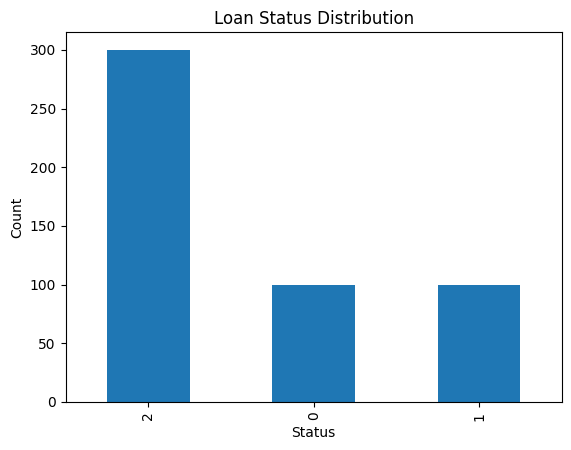

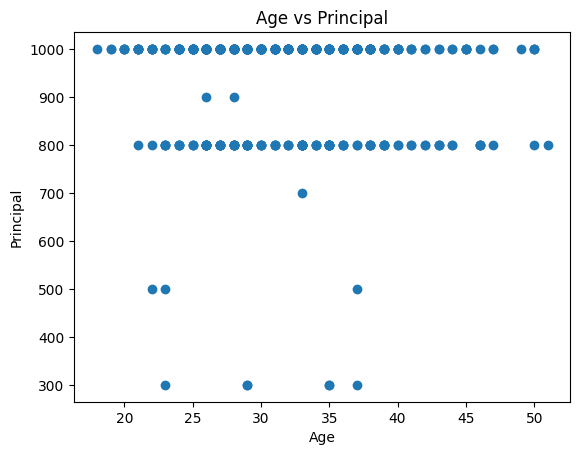

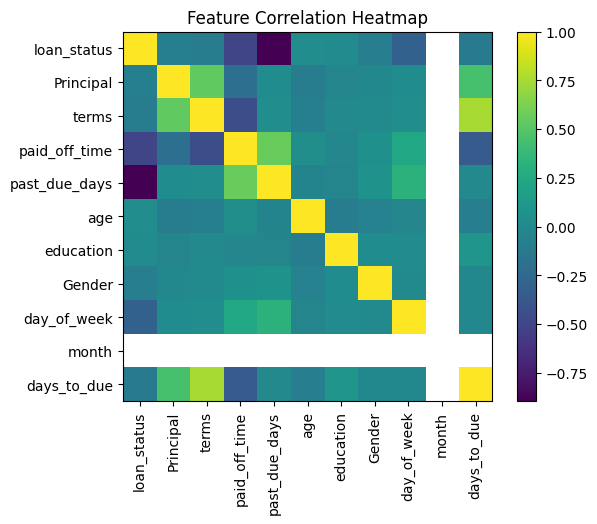


Model Accuracy: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      0.29      0.45        24
           2       0.75      1.00      0.86        52

    accuracy                           0.83       100
   macro avg       0.92      0.76      0.77       100
weighted avg       0.87      0.83      0.80       100



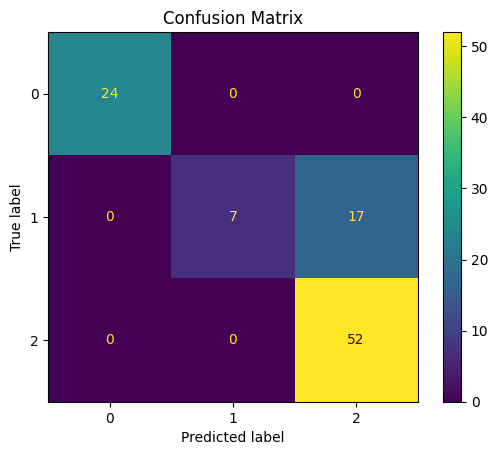

In [3]:
# ==========================================
# LOAN PREDICTION - LOGISTIC REGRESSION ONLY
# ==========================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# 2. LOAD DATA
df = pd.read_csv("/content/Loan payments data.csv")

print("Initial Data:\n", df.head())

# 3. DATA CLEANING

# Drop ID column
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# Convert date columns
df['effective_date'] = pd.to_datetime(df['effective_date'], errors='coerce')
df['due_date'] = pd.to_datetime(df['due_date'], errors='coerce')

# Feature Engineering
df['day_of_week'] = df['effective_date'].dt.dayofweek
df['month'] = df['effective_date'].dt.month
df['days_to_due'] = (df['due_date'] - df['effective_date']).dt.days

# Drop original date columns
df = df.drop(columns=['effective_date', 'due_date'])

# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Convert everything to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Handle missing values
df = df.fillna(0)

print("\nCleaned Data Types:\n", df.dtypes)

# 4. VISUALIZATION

# Target distribution
plt.figure()
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# Age vs Principal
plt.figure()
plt.scatter(df['age'], df['Principal'])
plt.title("Age vs Principal")
plt.xlabel("Age")
plt.ylabel("Principal")
plt.show()

# Correlation Heatmap
plt.figure()
corr = df.corr()
plt.imshow(corr)
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

# 5. SPLIT DATA
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. TRAIN LOGISTIC REGRESSION MODEL
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 8. PREDICTION
y_pred = model.predict(X_test)

# 9. EVALUATION

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()